# Task 3 (PoC)

# Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls '/content/drive/MyDrive/CSE424 Project'

'Pattern Recognition Project'
 Task1_LiteratureReview_24141071_NawrozHaseenTumul_CSE424.pdf


# Importing Basic Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Loading train dataset

In [ ]:
dataset_path = '/content/drive/MyDrive/CSE424 Project/Pattern Recognition Project/Crowdflower/labeled_data.csv'

tweet_data = pd.read_csv(dataset_path)

# EDA

# Data Overview

In [ ]:
display(tweet_data.describe())

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [ ]:
#first few rows of the dataset
print("First few rows of the dataset:")
print(tweet_data.head())

#basic information about the dataset (shape, column types)
print("\nBasic Information about the dataset:")
tweet_data_info = tweet_data.info()

#summary statistics (numerical columns)
print("\nSummary Statistics of the dataset:")
tweet_data_summary = tweet_data.describe()

#shape (rows, columns) of the dataset
print("\nShape of the dataset (rows, columns) :")
print(tweet_data.shape)

#column names
print("\nColumn names in the dataset:")
print(tweet_data.columns)

#count of each class
class_distribution = tweet_data['class'].value_counts()

#class distribution
print("\nClass Distribution:")
print(class_distribution)

First few rows of the dataset:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  

Basic Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  -

# Missing Value Analysis

Missing values per column:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Percentage of missing values per column:
Unnamed: 0            0.0
count                 0.0
hate_speech           0.0
offensive_language    0.0
neither               0.0
class                 0.0
tweet                 0.0
dtype: float64


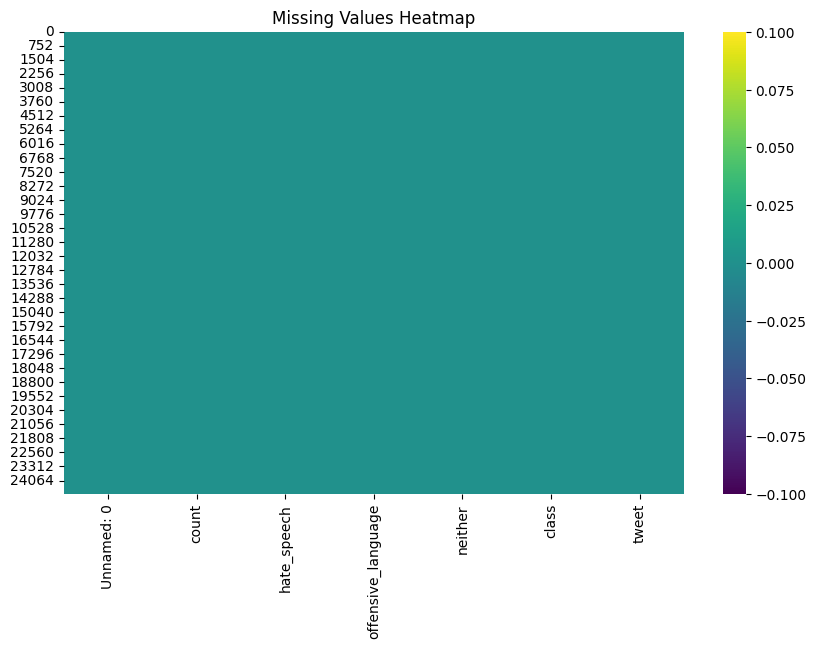

In [ ]:
#missing values in the dataset
missing_values = tweet_data.isnull().sum()

print("Missing values per column:")
print(missing_values)

missing_percentage = (missing_values / len(tweet_data)) * 100
print("\nPercentage of missing values per column:")
print(missing_percentage)

#visualizing using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(tweet_data.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


# Class Distribution Analysis

In [ ]:
#class mapping
print("Class value counts:")
class_counts = tweet_data['class'].value_counts()

#percentage
class_percentages = (class_counts / len(tweet_data)) * 100

class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})

#mapping class numbers to labels
class_distribution.index = class_distribution.index.map({
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'Neither'
})

print("Class Distribution:")
print(class_distribution)

Class value counts:
Class Distribution:
                    Count  Percentage
class                                
Offensive Language  19190   77.432111
Neither              4163   16.797805
Hate Speech          1430    5.770084


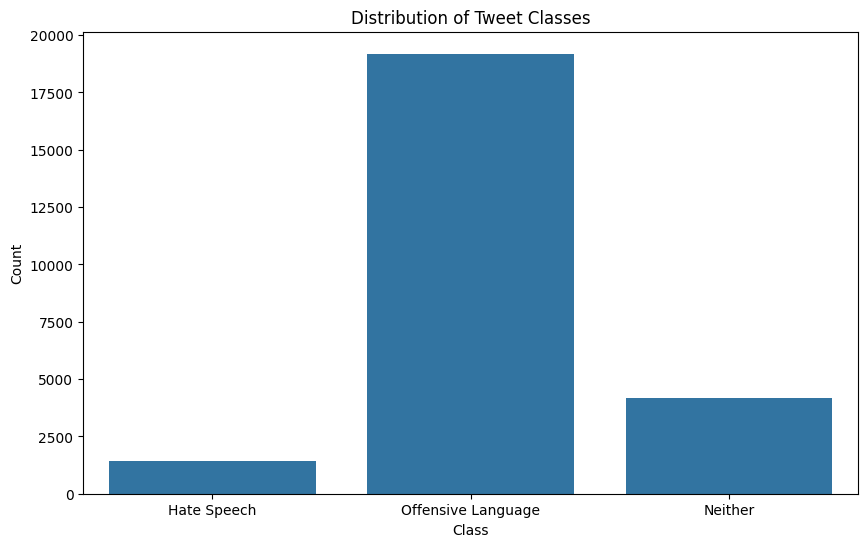

In [ ]:
#countplot for class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=tweet_data)
plt.title('Distribution of Tweet Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Hate Speech', 'Offensive Language', 'Neither'])
plt.show()

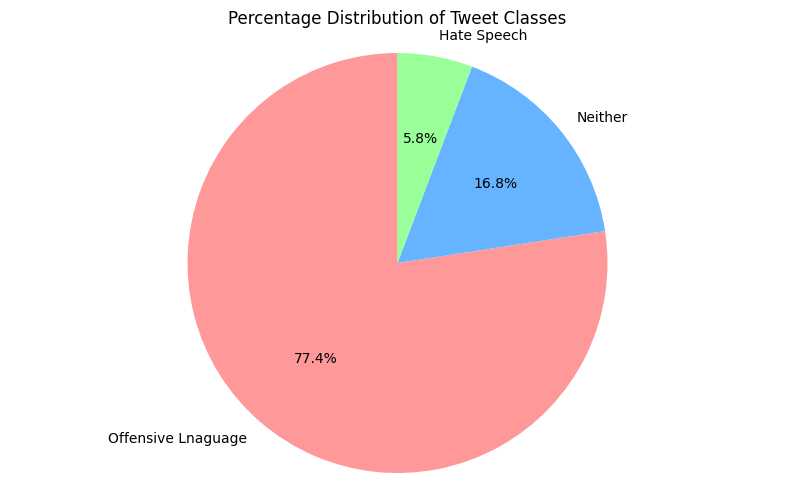

In [ ]:
#piechart for class distribution
plt.figure(figsize=(10, 6))
plt.pie(class_percentages,
        labels=['Offensive Lnaguage', 'Neither', 'Hate Speech'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage Distribution of Tweet Classes')
plt.axis('equal')
plt.show()

# Label Distribution Analysis

In [ ]:
#sum of each label column
label_sums = tweet_data[['hate_speech', 'offensive_language', 'neither']].sum()

#percentages
label_percentages = (label_sums / len(tweet_data)) * 100

label_distribution = pd.DataFrame({
    'Count': label_sums,
    'Percentage': label_percentages
})

print("\nIndividual Label Distribution:")
print(label_distribution)


Individual Label Distribution:
                    Count  Percentage
hate_speech          6952   28.051487
offensive_language  59819  241.371101
neither             13612   54.924747


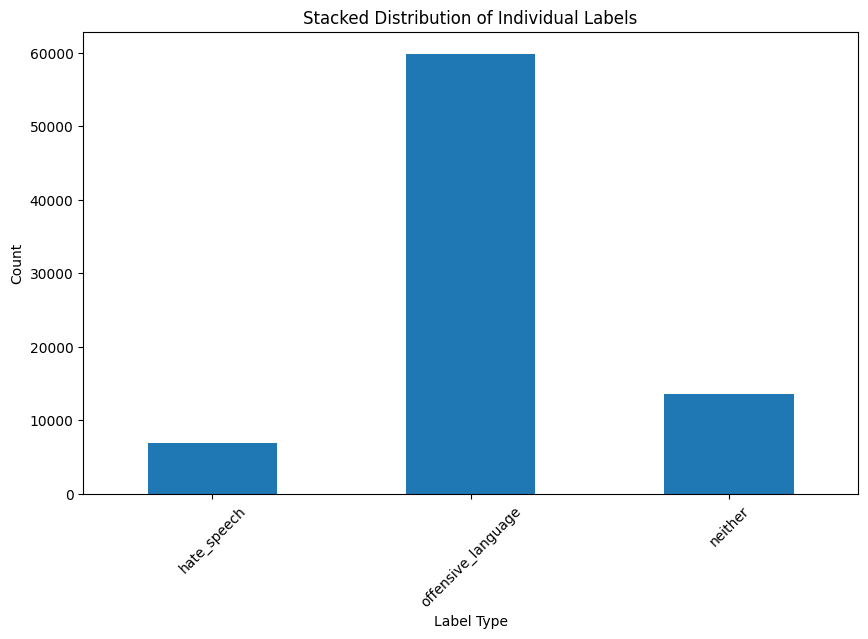

In [ ]:
label_cols = ['hate_speech', 'offensive_language', 'neither']
label_counts = tweet_data[label_cols].sum()

plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Stacked Distribution of Individual Labels')
plt.xlabel('Label Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

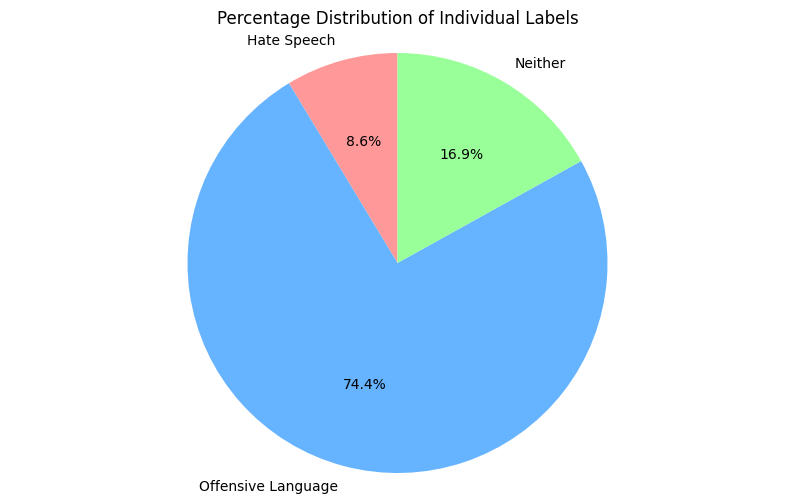

In [ ]:
#piechart for labels
plt.figure(figsize=(10, 6))
plt.pie(label_percentages,
        labels=['Hate Speech', 'Offensive Language', 'Neither'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage Distribution of Individual Labels')
plt.axis('equal')
plt.show()

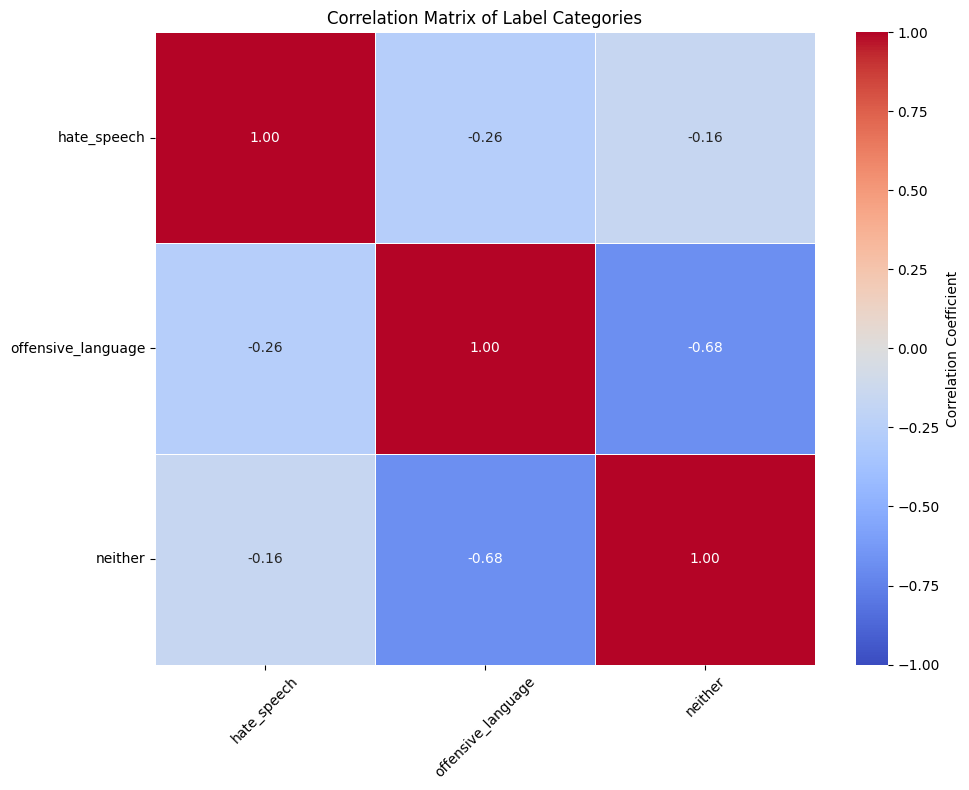

In [ ]:
#correlation matrix for label correlations
label_corr = tweet_data[['hate_speech', 'offensive_language', 'neither']].corr()

#heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(label_corr,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Label Categories')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Univariate Analysis: Tweet Length Distribution by Class

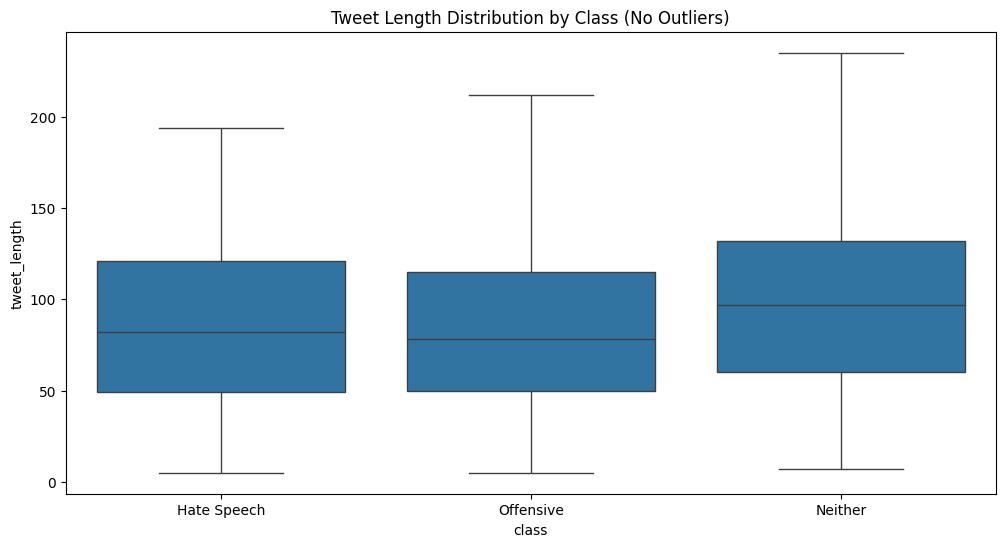

In [ ]:
#raw tweet length (character count)
tweet_data['tweet_length'] = tweet_data['tweet'].str.len()

# Plot length distribution per class
plt.figure(figsize=(12, 6))
sns.boxplot(data=tweet_data, x='class', y='tweet_length', showfliers=False)
plt.title("Tweet Length Distribution by Class (No Outliers)")
plt.xticks([0, 1, 2], ['Hate Speech', 'Offensive', 'Neither'])
plt.show()

# Bivariate Analysis: Hashtag/Mention Counts vs Class

In [ ]:
class_mapping = {
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'Neither'
}

#column with class names
tweet_data['class_name'] = tweet_data['class'].map(class_mapping)

#hashtags /mentions counts
tweet_data['hashtag_count'] = tweet_data['tweet'].str.count('#')
tweet_data['mention_count'] = tweet_data['tweet'].str.count('@')

#hashtag/mention means
print("\nAverage Hashtags per Class:")
print(tweet_data.groupby('class_name')['hashtag_count'].mean().sort_values(ascending=False))

print("\nAverage Mentions per Class:")
print(tweet_data.groupby('class_name')['mention_count'].mean().sort_values(ascending=False))

#flags for hashtags/mentions
tweet_data['has_hashtag'] = tweet_data['hashtag_count'] > 0
tweet_data['has_mention'] = tweet_data['mention_count'] > 0

#class distribution for these flags
print("\nTweets with Hashtags by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag']))

print("\nTweets with Mentions by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_mention']))

print("\nPercentage of Tweets with Hashtags by Class:")
print(pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag'], normalize='index').round(2))


Average Hashtags per Class:
class_name
Neither               0.819361
Offensive Language    0.793695
Hate Speech           0.483217
Name: hashtag_count, dtype: float64

Average Mentions per Class:
class_name
Hate Speech           0.946853
Neither               0.864761
Offensive Language    0.755446
Name: mention_count, dtype: float64

Tweets with Hashtags by Class:
has_hashtag         False  True 
class_name                      
Hate Speech          1101    329
Neither              2609   1554
Offensive Language  13428   5762

Tweets with Mentions by Class:
has_mention         False  True 
class_name                      
Hate Speech           513    917
Neither              1621   2542
Offensive Language   8423  10767

Percentage of Tweets with Hashtags by Class:
has_hashtag         False  True 
class_name                      
Hate Speech          0.77   0.23
Neither              0.63   0.37
Offensive Language   0.70   0.30


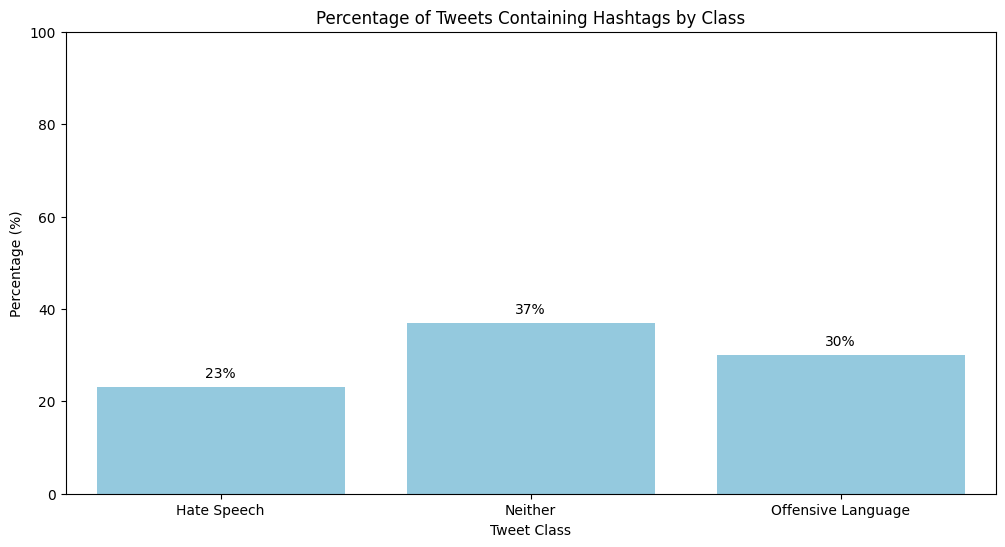

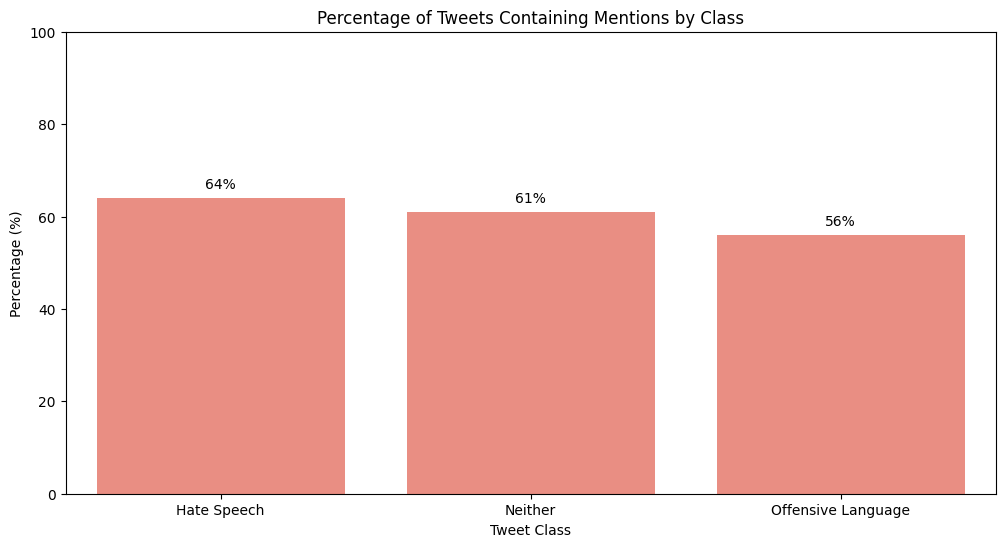

In [ ]:
hashtag_percent = pd.crosstab(tweet_data['class_name'], tweet_data['has_hashtag'], normalize='index').round(2) * 100
mention_percent = pd.crosstab(tweet_data['class_name'], tweet_data['has_mention'], normalize='index').round(2) * 100

#hashtags
plt.figure(figsize=(12, 6))
sns.barplot(data=hashtag_percent.reset_index(), x='class_name', y=True, color='skyblue')
plt.title('Percentage of Tweets Containing Hashtags by Class')
plt.xlabel('Tweet Class')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.0f}%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0, 10),
                      textcoords='offset points')
plt.show()

#mentions
plt.figure(figsize=(12, 6))
sns.barplot(data=mention_percent.reset_index(), x='class_name', y=True, color='salmon')
plt.title('Percentage of Tweets Containing Mentions by Class')
plt.xlabel('Tweet Class')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.0f}%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0, 10),
                      textcoords='offset points')
plt.show()

# Outlier Analysis: Tweet Length

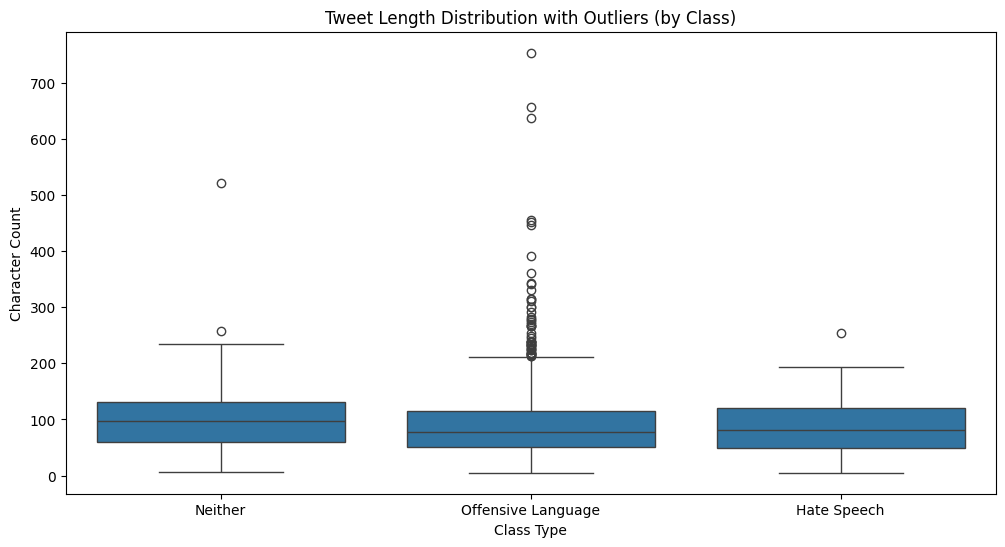

In [ ]:
tweet_data['tweet_length'] = tweet_data['tweet'].str.len()


#boxploat: tweet length by class
plt.figure(figsize=(12, 6))
sns.boxplot(x='class_name', y='tweet_length', data=tweet_data, showfliers=True)
plt.title('Tweet Length Distribution with Outliers (by Class)')
plt.ylabel('Character Count')
plt.xlabel('Class Type')
plt.show()

Found 59 length outliers (0.24% of data)

Tweet length outlier count per class:
class_name
Offensive Language    52
Neither                6
Hate Speech            1
Name: count, dtype: int64


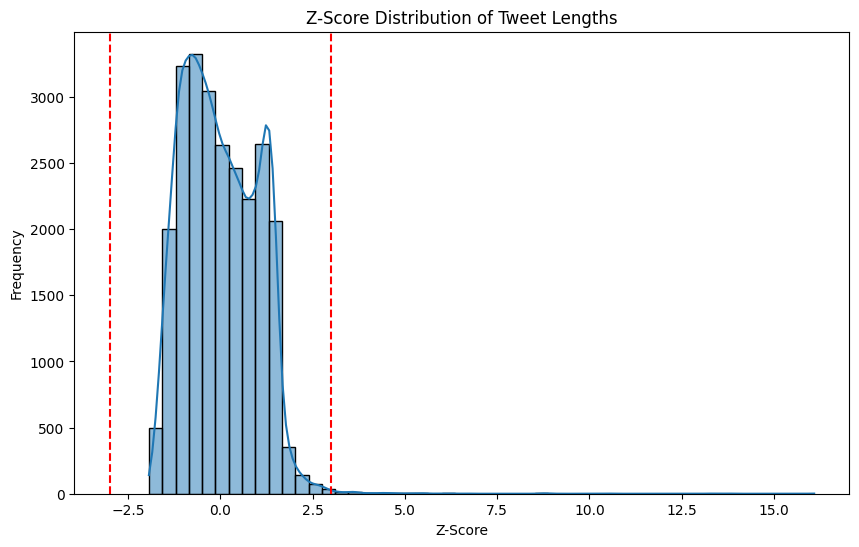

In [ ]:
#z-scores for tweet length
tweet_data['length_zscore'] = stats.zscore(tweet_data['tweet_length'])

#outliers (absolute z-score > 3)
outliers = tweet_data[np.abs(tweet_data['length_zscore']) > 3]
print(f"Found {len(outliers)} length outliers ({len(outliers)/len(tweet_data):.2%} of data)")

# Print outlier count per class
print("\nTweet length outlier count per class:")
print(outliers['class_name'].value_counts())

#z-score distribution
plt.figure(figsize=(10, 6))
sns.histplot(tweet_data['length_zscore'], bins=50, kde=True)
plt.axvline(x=3, color='r', linestyle='--')
plt.axvline(x=-3, color='r', linestyle='--')
plt.title('Z-Score Distribution of Tweet Lengths')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

# Pre-Processing

clean text

In [ ]:
import re

def clean_text(tweet):
    # Remove mentions (@...)
    tweet = re.sub(r'@\w+', '', tweet)
    # Remove hashtags (#...)
    tweet = re.sub(r'#\w+', '', tweet)
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    # Remove special characters and punctuation
    tweet = re.sub(r'[^A-Za-z0-9 ]', '', tweet)
    # Remove extra whitespace
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    return tweet

tweet_data['cleaned_tweet'] = tweet_data['tweet'].apply(clean_text)

print("Original tweet examples:")
print(tweet_data['tweet'].head())
print("\nCleaned tweet examples:")
print(tweet_data['cleaned_tweet'].head())

Original tweet examples:
0    !!! RT @mayasolovely: As a woman you shouldn't...
1    !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2    !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3    !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4    !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
Name: tweet, dtype: object

Cleaned tweet examples:
0    RT As a woman you shouldnt complain about clea...
1    RT boy dats coldtyga dwn bad for cuffin dat ho...
2    RT Dawg RT You ever fuck a bitch and she start...
3                            RT she look like a tranny
4    RT The shit you hear about me might be true or...
Name: cleaned_tweet, dtype: object


Tweet length outlier correction

In [ ]:
# Deal with outliers (tweet length outliers)
# We identified tweet length outliers in the previous step using Z-scores.
# Since the number of outliers is relatively small (0.24%), we will remove them.

print(f"Original dataset size: {len(tweet_data)}")
# Remove rows where the absolute z-score of 'tweet_length' is greater than 3
tweet_data = tweet_data[np.abs(tweet_data['length_zscore']) <= 3.5].copy()

print(f"Dataset size after removing tweet length outliers: {len(tweet_data)}")

Original dataset size: 24783
Dataset size after removing tweet length outliers: 24740


In [ ]:
tweet_data.shape

(24740, 15)

In [ ]:
from sklearn.utils import resample

# Separate classes
offensive = tweet_data[tweet_data['class'] == 1]
hate_speech = tweet_data[tweet_data['class'] == 0]
neither = tweet_data[tweet_data['class'] == 2]

# Undersample Offensive Language to match Neither (or a target size, e.g., 5,000)
offensive_downsampled = resample(offensive, n_samples= 5000, random_state=42)

#oversample hateful language
hate_speech_upsampled = resample(hate_speech, replace=True, n_samples=len(hate_speech)*2, random_state=42)

# Combine back into a balanced dataset
balanced_data = pd.concat([offensive_downsampled, hate_speech_upsampled, neither])

print(f"Dataset size after undersampling: {len(balanced_data)}")
print("Class distribution after undersampling:")
print(balanced_data['class'].value_counts())

Dataset size after undersampling: 12017
Class distribution after undersampling:
class
1    5000
2    4159
0    2858
Name: count, dtype: int64


In [ ]:
print(f"Dataset size after SMOTE: {len(balanced_data)}")
print("Class distribution after SMOTE:")
print(balanced_data['class'].value_counts())

Dataset size after SMOTE: 12017
Class distribution after SMOTE:
class
1    5000
2    4159
0    2858
Name: count, dtype: int64


In [ ]:
balanced_data.shape

(12017, 15)

In [ ]:
balanced_data.head(10)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,tweet_length,class_name,hashtag_count,mention_count,has_hashtag,has_mention,length_zscore,cleaned_tweet
20563,21010,7,1,6,0,1,"Run it up first , these hoes come later&#9996;...",54,Offensive Language,2,0,True,False,-0.756631,Run it up first these hoes come later
1121,1146,3,0,3,0,1,&#8220;@BINDLE13: My momma aint raise no hoe&#...,51,Offensive Language,2,1,True,True,-0.828838,My momma aint raise no hoe
7297,7505,3,0,3,0,1,@wodaeeex3 @aaliyahh_lovee yu betta watch cho ...,71,Offensive Language,0,2,False,True,-0.347460,yu betta watch cho mouf bout dat one dea hoe
15634,16000,3,0,3,0,1,RT @ImNotTwitFamous: How to deal with cyber bu...,110,Offensive Language,0,1,False,True,0.591227,RT How to deal with cyber bulling1log out2go o...
14777,15131,3,0,3,0,1,RT @CorySayFukEm: i love girls who aren't afra...,146,Offensive Language,1,1,True,True,1.457707,RT i love girls who arent afraid to encourage ...
8382,8614,3,0,3,0,1,Carl try eat the pussy but that big ass nose b...,63,Offensive Language,0,0,False,False,-0.540011,Carl try eat the pussy but that big ass nose b...
21909,22376,3,0,3,0,1,Thirsty bitches&lt;&lt;&lt;&lt; Not attractive,46,Offensive Language,0,0,False,False,-0.949183,Thirsty bitchesltltltlt Not attractive
5944,6115,3,0,3,0,1,@esn_Josh @esn_Waves @ESN_Creeper @GT_Partheno...,115,Offensive Language,0,4,False,True,0.711571,bitch please are you trying to say I was close...
18772,19188,3,0,3,0,1,RT @ckillaTRIPPY: Im a knock the pussy out lik...,59,Offensive Language,0,1,False,True,-0.636287,RT Im a knock the pussy out like fight night
14869,15225,3,0,3,0,1,RT @DJZeeti: Marriage not for everyone.. Some ...,88,Offensive Language,0,1,False,True,0.061711,RT Marriage not for everyone Some bitches just...


In [ ]:
#Calculate cleaned tweet length
balanced_data['cleaned_tweet_length'] = balanced_data['cleaned_tweet'].str.len()

#Count hashtags (already done in previous cell, keeping for completeness)
#Count mentions (already done in previous cell, keeping for completeness)

print(balanced_data['cleaned_tweet_length'].head())
print(balanced_data['hashtag_count'].head())
print(balanced_data['mention_count'].head())

20563     37
1121      26
7297      44
15634     80
14777    119
Name: cleaned_tweet_length, dtype: int64
20563    2
1121     2
7297     0
15634    0
14777    1
Name: hashtag_count, dtype: int64
20563    0
1121     1
7297     2
15634    1
14777    1
Name: mention_count, dtype: int64


In [ ]:
def calculate_average_word_length(tweet):
    # Ensure tweet is a string and handle empty cases
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0
    # Split into words (using space as delimiter, consistent with cleaned text)
    words = tweet.split()
    if not words:
        return 0.0
    # Total characters excluding spaces
    total_chars = sum(len(word) for word in words)
    # Number of words
    num_words = len(words)
    return total_chars / num_words

# Calculate average word length for cleaned tweets
balanced_data['avg_word_length'] = balanced_data['cleaned_tweet'].apply(calculate_average_word_length)

# Verify
print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nAverage word length examples:")
print(balanced_data['avg_word_length'].head())

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Average word length examples:
20563    3.750000
1121     3.500000
7297     3.500000
15634    4.785714
14777    4.454545
Name: avg_word_length, dtype: float64


In [ ]:
# Uninstall existing versions
#!pip uninstall -y transformers torch

# Install compatible versions
#!pip install transformers==4.35.2 torch==2.5.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

# Verify installation
#import transformers
#import torch
#print(f"Transformers version: {transformers.__version__}")
#print(f"Torch version: {torch.__version__}")
#print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pandas as pd

# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize BERTweet tokenizer and model with error handling and retry
max_retries = 2
for attempt in range(max_retries):
    try:
        tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")
        model = AutoModel.from_pretrained("vinai/bertweet-base").to(device)
        print(f"Successfully loaded BERTweet on attempt {attempt + 1}")
        break
    except Exception as e:
        print(f"Attempt {attempt + 1} failed: {e}")
        if attempt == max_retries - 1:
            raise
        print("Retrying after a short delay...")
        import time; time.sleep(5)  # Wait 5 seconds before retrying

# Function to get BERT embeddings with error handling and dynamic batching
def get_bert_embeddings(tweets, batch_size=32, max_length=128):
    if not isinstance(tweets, (pd.Series, list, np.ndarray)):
        raise ValueError("Input 'tweets' must be a pandas Series, list, or numpy array")

    # Ensure tweets are strings and handle empty or invalid entries
    tweets = [str(tweet) if pd.notna(tweet) and tweet != "" else "" for tweet in tweets]

    embeddings = []
    for i in tqdm(range(0, len(tweets), batch_size), desc="Generating BERT embeddings"):
        batch_tweets = tweets[i:i + batch_size]
        try:
            # Tokenize batch
            inputs = tokenizer(
                batch_tweets,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            # Get embeddings
            with torch.no_grad():
                outputs = model(**inputs)
                # Mean-pool the last hidden state to get tweet-level embeddings (768D)
                batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_embeddings)
        except RuntimeError as e:
            print(f"Memory error or CUDA out of memory at batch {i}. Reducing batch size to {max(batch_size // 2, 8)}")
            batch_size = max(batch_size // 2, 8)  # Halve batch size, minimum 8 for GPU efficiency
            continue  # Skip this batch and proceed with reduced size

    if not embeddings:
        raise RuntimeError("No embeddings generated. Check input data or device.")

    return np.vstack(embeddings)

# Apply to cleaned tweet text (before lemmatization, stop-word removal, TF-IDF)
try:
    if 'cleaned_tweet' not in balanced_data.columns:
        raise KeyError("Column 'cleaned_tweet' not found in balanced_data. Ensure clean_text was applied.")

    bert_embeddings = get_bert_embeddings(balanced_data['cleaned_tweet'], batch_size=64)  # Optimized for GPU

    print("BERT embeddings shape:", bert_embeddings.shape)
    # Note: Combine with TF-IDF later after computing tfidf_matrix (e.g., combined_features = hstack([tfidf_matrix, bert_embeddings]))
except Exception as e:
    print(f"Error during embedding generation: {e}")
    raise

Using device: cuda


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Successfully loaded BERTweet on attempt 1


Generating BERT embeddings: 100%|██████████| 188/188 [00:24<00:00,  7.61it/s]

BERT embeddings shape: (12017, 768)


In [ ]:
balanced_data['bert_embeddings'] = list(bert_embeddings)
print(bert_embeddings)

[[-0.03626371  0.16409789  0.11044485 ... -0.03782372 -0.00831503
  -0.18535493]
 [-0.00904158  0.24901986  0.27470276 ...  0.0641653   0.06377672
  -0.1055465 ]
 [ 0.08636299  0.16022521  0.21715099 ...  0.0132388   0.1446722
  -0.06544539]
 ...
 [ 0.10528999  0.11619919 -0.01041587 ...  0.06553233  0.2204527
  -0.02655737]
 [-0.05389279  0.11520187  0.02109619 ... -0.0772502   0.15598495
  -0.05940109]
 [-0.1660443   0.0886569   0.15515816 ...  0.0218491   0.1366925
  -0.09891091]]


In [ ]:
import nltk
from nltk.tokenize import word_tokenize

#punkt tokenizer
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Handle potential encoding issues before tokenization
balanced_data['cleaned_tweet'] = balanced_data['cleaned_tweet'].str.encode('ascii', 'ignore').str.decode('ascii')

balanced_data['tokens'] = balanced_data['cleaned_tweet'].apply(word_tokenize)

In [ ]:
print("Original tweet examples:")
print(balanced_data['tweet'].head())
print("\nCleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nTokenized tweet examples:")
print(balanced_data['tokens'].head())

Original tweet examples:
20563    Run it up first , these hoes come later&#9996;...
1121     &#8220;@BINDLE13: My momma aint raise no hoe&#...
7297     @wodaeeex3 @aaliyahh_lovee yu betta watch cho ...
15634    RT @ImNotTwitFamous: How to deal with cyber bu...
14777    RT @CorySayFukEm: i love girls who aren't afra...
Name: tweet, dtype: object

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Tokenized tweet examples:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, 

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download WordNet and the POS tagger
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tags to first letter used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"N": wordnet.NOUN,
                "V": wordnet.VERB,
                "A": wordnet.ADJ,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

balanced_data['tokens_lemmatized'] = balanced_data['tokens'].apply(lambda tokens: [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens])

In [ ]:
print("\nTokens before lemmatization:")
print(balanced_data['tokens'].head(15))
print("\nTokens after lemmatization:")
print(balanced_data['tokens_lemmatized'].head(15))


Tokens before lemmatization:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, arent, afraid, to, e...
8382     [Carl, try, eat, the, pussy, but, that, big, a...
21909          [Thirsty, bitchesltltltlt, Not, attractive]
5944     [bitch, please, are, you, trying, to, say, I, ...
18772    [RT, Im, a, knock, the, pussy, out, like, figh...
14869    [RT, Marriage, not, for, everyone, Some, bitch...
20843    [Side, bitches, are, basically, new, relations...
11039    [I, was, a, huge, tomboy, Like, I, had, barbie...
2096     [See, I, got, ta, get, this, money, ma, palms,...
1010       [RT, Hood, hoes, love, Harrell, football, team]
3137               [they, can, see, this, dumbass, nigger]
Name: tokens, dtype: object

Tokens after lemmatization:
20563        [Run, it, up, f

In [ ]:
from nltk.corpus import stopwords

# Download stop words
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))

balanced_data['tokens_no_stopwords'] = balanced_data['tokens'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])

In [ ]:
print("\nTokens before stop word removal:")
print(balanced_data['tokens'].head(15))
print("\nTokens after stop word removal:")
print(balanced_data['tokens_no_stopwords'].head(15))


Tokens before stop word removal:
20563       [Run, it, up, first, these, hoes, come, later]
1121                     [My, momma, aint, raise, no, hoe]
7297     [yu, betta, watch, cho, mouf, bout, dat, one, ...
15634    [RT, How, to, deal, with, cyber, bulling1log, ...
14777    [RT, i, love, girls, who, arent, afraid, to, e...
8382     [Carl, try, eat, the, pussy, but, that, big, a...
21909          [Thirsty, bitchesltltltlt, Not, attractive]
5944     [bitch, please, are, you, trying, to, say, I, ...
18772    [RT, Im, a, knock, the, pussy, out, like, figh...
14869    [RT, Marriage, not, for, everyone, Some, bitch...
20843    [Side, bitches, are, basically, new, relations...
11039    [I, was, a, huge, tomboy, Like, I, had, barbie...
2096     [See, I, got, ta, get, this, money, ma, palms,...
1010       [RT, Hood, hoes, love, Harrell, football, team]
3137               [they, can, see, this, dumbass, nigger]
Name: tokens, dtype: object

Tokens after stop word removal:
20563               

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert the list of tokens back to strings for vectorization
balanced_data['text_for_vectorization'] = balanced_data['tokens_no_stopwords'].apply(lambda tokens: ' '.join(tokens))

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(balanced_data['text_for_vectorization'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (12017, 5000)


In [ ]:
#Summarized TF-IDF matrix
print("\nTF-IDF Matrix Summary:")
print(f"Shape: {tfidf_matrix.shape}")
print("Sample values (first 5 rows, first 5 columns):")
print(tfidf_matrix[:5, :5].toarray())  # Convert sparse slice to dense for display


TF-IDF Matrix Summary:
Shape: (12017, 5000)
Sample values (first 5 rows, first 5 columns):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


Most Common Words:
[('RT', 3556), ('bitch', 2479), ('like', 1173), ('trash', 975), ('bitches', 855), ('hoes', 681), ('Im', 680), ('dont', 669), ('pussy', 633), ('ass', 613), ('hoe', 609), ('got', 581), ('get', 578), ('u', 533), ('amp', 464), ('nigga', 463), ('fuck', 447), ('faggot', 416), ('shit', 379), ('know', 354)]


/tmp/ipython-input-2703281051.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=most_common_df, palette='viridis')


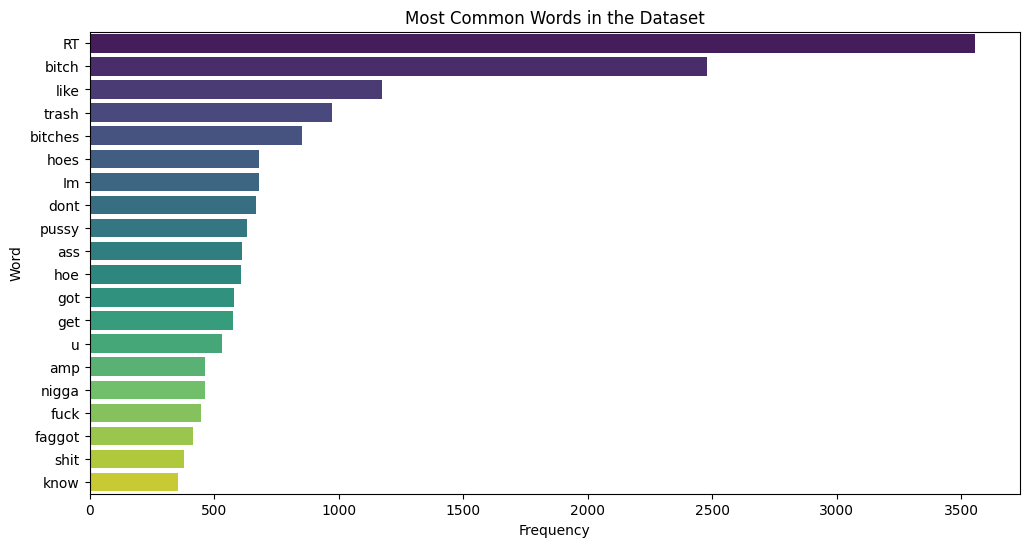

In [ ]:
from collections import Counter

# Join all lemmatized tokens into a single string
all_words = ' '.join(balanced_data['text_for_vectorization'])

# Get the most common words
most_common_words = Counter(all_words.split()).most_common(20) # Adjust the number as needed

# Print the most common words
print("Most Common Words:")
print(most_common_words)

# Create a DataFrame for plotting
most_common_df = pd.DataFrame(most_common_words, columns=['word', 'count'])

# Plot a bar chart of the most common words
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='word', data=most_common_df, palette='viridis')
plt.title('Most Common Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

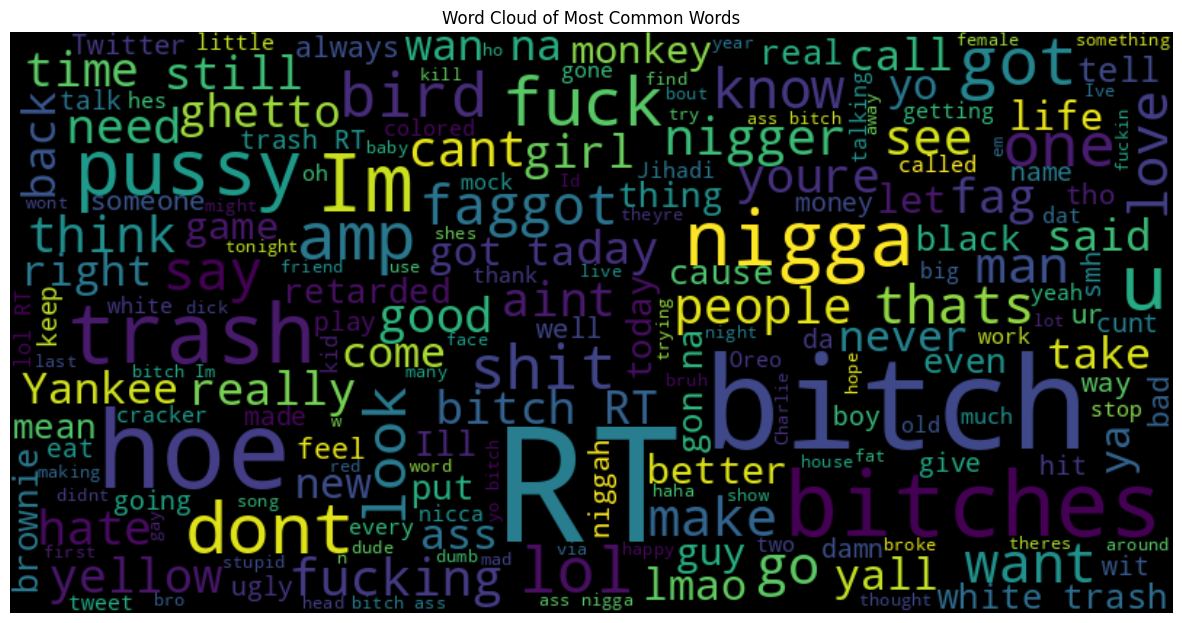

In [ ]:
from wordcloud import WordCloud

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Most Common Words')
plt.show()

# Task
Preprocess the dataset "twitter_training.csv" and "twitter_validation.csv" by performing data cleaning, tokenization, removing stop words, stemming/lemmatization, feature engineering, and handling imbalanced data. Then, split the data into training and testing sets.

## Feature engineering

### Subtask:
Create new features from the existing data that might improve model performance (e.g., tweet length, number of hashtags, sentiment scores).


**Reasoning**:
Calculate the length of the cleaned tweets, count hashtags and mentions in the original tweets, and calculate sentiment scores for the cleaned tweets, adding these as new features to the tweet_data DataFrame.



In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
from tqdm import tqdm

try:
    analyzer = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')
    analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(tweet):
    if not isinstance(tweet, str) or pd.isna(tweet):
        return 0.0
    scores = analyzer.polarity_scores(tweet)
    return scores['compound']

batch_size = 1000
sentiment_scores = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating sentiment scores"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_scores = [get_sentiment_score(tweet) for tweet in batch]
    sentiment_scores.extend(batch_scores)

balanced_data['sentiment_score'] = sentiment_scores

print("Sentiment score examples:")
print(balanced_data['sentiment_score'].head())

Calculating sentiment scores: 100%|██████████| 13/13 [00:03<00:00,  4.30it/s]

Sentiment score examples:
20563    0.0000
1121     0.2235
7297     0.0000
15634    0.0000
14777   -0.4592
Name: sentiment_score, dtype: float64


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import pandas as pd
from tqdm import tqdm

try:
    nltk.data.find('averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')
try:
    nltk.data.find('punkt')
except LookupError:
    nltk.download('punkt')

def calculate_lexical_density(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0
    tokens = word_tokenize(tweet.lower())
    if not tokens:
        return 0.0
    # POS tag the tokens
    pos_tags = pos_tag(tokens)
    # Count lexical words (nouns, verbs, adjectives, adverbs)
    lexical_count = sum(1 for _, tag in pos_tags if tag.startswith(('NN', 'VB', 'JJ', 'RB')))
    total_words = len(tokens)
    return lexical_count / total_words if total_words > 0 else 0.0

batch_size = 1000
lexical_densities = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating lexical densities"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_densities = [calculate_lexical_density(tweet) for tweet in batch]
    lexical_densities.extend(batch_densities)

balanced_data['lexical_density'] = lexical_densities

print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nLexical density examples:")
print(balanced_data['lexical_density'].head())

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Calculating lexical densities: 100%|██████████| 13/13 [00:12<00:00,  1.08it/s]

Cleaned tweet examples:
20563                Run it up first these hoes come later
1121                            My momma aint raise no hoe
7297          yu betta watch cho mouf bout dat one dea hoe
15634    RT How to deal with cyber bulling1log out2go o...
14777    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Lexical density examples:
20563    0.625000
1121     0.666667
7297     0.800000
15634    0.642857
14777    0.772727
Name: lexical_density, dtype: float64


In [ ]:
!pip install textstat

In [ ]:
import pandas as pd
from textstat import textstat
from tqdm import tqdm

try:
    import textstat
except ImportError:
    !pip install textstat
    import textstat


balanced_data = balanced_data.reset_index(drop=True)

def calculate_readability_scores(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'flesch_kincaid': 0.0, 'flesch_ease': 0.0, 'gunning_fog': 0.0}

    flesch_kincaid = textstat.flesch_kincaid_grade(tweet)
    flesch_ease = textstat.flesch_reading_ease(tweet)
    gunning_fog = textstat.gunning_fog(tweet)
    return {'flesch_kincaid': flesch_kincaid, 'flesch_ease': flesch_ease, 'gunning_fog': gunning_fog}

batch_size = 1000
readability_scores = []
for i in tqdm(range(0, len(balanced_data), batch_size), desc="Calculating readability scores"):
    batch = balanced_data['cleaned_tweet'].iloc[i:i + batch_size]
    batch_scores = [calculate_readability_scores(tweet) for tweet in batch]
    readability_scores.extend(batch_scores)

readability_df = pd.DataFrame(readability_scores)
balanced_data = pd.concat([balanced_data, readability_df], axis=1)

print("Cleaned tweet examples:")
print(balanced_data['cleaned_tweet'].head())
print("\nReadability score examples:")
print(balanced_data[['flesch_kincaid', 'flesch_ease', 'gunning_fog']].head())

Calculating readability scores: 100%|██████████| 13/13 [00:01<00:00, 12.17it/s]

Cleaned tweet examples:
0                Run it up first these hoes come later
1                           My momma aint raise no hoe
2         yu betta watch cho mouf bout dat one dea hoe
3    RT How to deal with cyber bulling1log out2go o...
4    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object

Readability score examples:
   flesch_kincaid  flesch_ease  gunning_fog
0        0.805000   103.540000     3.200000
1        0.516667   102.045000     2.400000
2        1.290000   103.625000     4.000000
3        7.570000    65.725000     8.457143
4        9.080909    69.141364    12.436364


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
sid = SentimentIntensityAnalyzer()

def calculate_sentiment_shift(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0.0

    words = tweet.split()
    if len(words) < 2:
        return 0.0

    # Split into two halves based on word count
    split_point = len(words) // 2
    seg1 = ' '.join(words[:split_point])
    seg2 = ' '.join(words[split_point:])
    segments = [seg1, seg2]

    # Compute sentiment scores for each segment
    sentiment_scores = [sid.polarity_scores(seg)['compound'] for seg in segments]

    # Calculate absolute difference
    return abs(sentiment_scores[1] - sentiment_scores[0])

balanced_data['sentiment_shift'] = balanced_data['cleaned_tweet'].apply(calculate_sentiment_shift)
print(balanced_data['cleaned_tweet'].head())
print(balanced_data['sentiment_shift'].head())

0                Run it up first these hoes come later
1                           My momma aint raise no hoe
2         yu betta watch cho mouf bout dat one dea hoe
3    RT How to deal with cyber bulling1log out2go o...
4    RT i love girls who arent afraid to encourage ...
Name: cleaned_tweet, dtype: object
0    0.0000
1    0.2960
2    0.0000
3    0.0000
4    1.5031
Name: sentiment_shift, dtype: float64


In [ ]:
#feature: N-Gram Patterns (Bigrams/Trigrams) using TfidfVectorizer

ngram_vectorizer = TfidfVectorizer(ngram_range=(2, 3), max_features=2000, analyzer='word')
ngram_matrix = ngram_vectorizer.fit_transform(balanced_data['cleaned_tweet'])

print("Top 10 bigrams/trigrams:")
print(ngram_vectorizer.get_feature_names_out()[:10])

Top 10 bigrams/trigrams:
['7186220221 24' 'about how' 'about it' 'about that' 'about the'
 'about this' 'about to' 'about what' 'about yall' 'about yall eyebrows']


In [ ]:
#Slang/Dialect Markers

slang_patterns = [
    r'\bh8\b',
    r'\bh@te\b',
    r'\bn1gger\b',
    r'\bn\*gger\b',
    r'\bnigg?r\b',
    r'\bf@g\b',
    r'\bf4g\b',
    r'\bk1ke\b',
    r'\bk\*ke\b',
    r'\bj3w\b',
    r'\bch1nk\b',
    r'\bsp1c\b',
    r'\bw3tb4ck\b',
    r'\bt4rd\b',
    r'\br3t4rd\b',
    r'\btr4nny\b',
    r'\btr\*nny\b',
    r'\bwh0re\b',
    r'\bc\*nt\b',
    r'\bb1tch\b',
    r'\bsh1t\b',
    r'\bj1hadi\b',
    r'\bjih@di\b',
    r'\bjihad1\b',
    r'\bfck\b',
    r'\bfuk\b',
    r'\bd1ke\b',
    r'\bkys\b',
    r'\bcoon\b',
    r'\bgypo\b',
    r'\bchinks\b',
    r'\bspics\b',
    r'\bretard\b',
    r'\bfaggot\b'
    # General patterns for censored words
    r'\b\w*[\d@*]+\w*\b'    # Words with numbers/symbols (e.g., h8, n*gg*r)
]

slang_regex = re.compile('|'.join(slang_patterns), re.IGNORECASE)

def count_slang_markers(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return 0
    matches = slang_regex.findall(tweet)
    return len(matches)

balanced_data['slang_marker_count'] = balanced_data['cleaned_tweet'].apply(count_slang_markers)

print("Slang marker count distribution:")
print(balanced_data['slang_marker_count'].describe())
print("\nSample tweets with slang markers (>0):")
print(balanced_data[balanced_data['slang_marker_count'] > 0][['cleaned_tweet', 'slang_marker_count']].head(10))

Slang marker count distribution:
count    12017.000000
mean         0.013731
std          0.116375
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: slang_marker_count, dtype: float64

Sample tweets with slang markers (>0):
                                         cleaned_tweet  slang_marker_count
133  RT Full retard NAR blaming slow April sales on...                   1
425  If you act like a fucking retard when your hig...                   1
483  Fluffy is a retard homeboy is calling a baby r...                   1
496  when youre stupid you dont know it life is so ...                   1
575           man fck dat tranny Juwanna man ass nigga                   1
643  bitch I aint arguing with you Fuk on You said ...                   1
796                Cant fuck with a coon ass girl bruh                   1
852  Bitch fuk wat a hater gotta say brickk ent ya ...                   1
978  Well now that Im basically gon

In [ ]:
#feature: Named Entity Recognition (NER)

ner_patterns = {
    'race_nationality': [
        r'\bafrican\b', r'\basian\b', r'\bblack\b', r'\bwhite\b', r'\blatino\b', r'\bhispanic\b',
        r'\bindian\b', r'\barab\b', r'\bjewish\b', r'\bchinese\b', r'\bmexican\b', r'\bafrican american\b',
        r'\bcaucasian\b', r'\bindigenous\b', r'\bnative american\b', r'\bimmigrant\b'
    ],
    'religion': [
        r'\bmuslim\b', r'\bchristian\b', r'\bjew\b', r'\bhindu\b', r'\bbuddhist\b', r'\bsikh\b',
        r'\bathiest\b', r'\bislam\b', r'\bchristianity\b', r'\bjudaism\b', r'\bzionist\b'
    ],
    'public_figures': [
        r'\bobama\b', r'\btrump\b', r'\bbiden\b', r'\bclinton\b', r'\bputin\b', r'\bkim\b',
        r'\belon musk\b', r'\bmark zuckerberg\b', r'\btaylor swift\b'
    ]
}

race_regex = re.compile('|'.join(ner_patterns['race_nationality']), re.IGNORECASE)
religion_regex = re.compile('|'.join(ner_patterns['religion']), re.IGNORECASE)
figures_regex = re.compile('|'.join(ner_patterns['public_figures']), re.IGNORECASE)

def count_targeted_entities(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'race_count': 0, 'religion_count': 0, 'figures_count': 0}
    race_matches = len(race_regex.findall(tweet))
    religion_matches = len(religion_regex.findall(tweet))
    figures_matches = len(figures_regex.findall(tweet))
    return {'race_count': race_matches, 'religion_count': religion_matches, 'figures_count': figures_matches}

ner_results = [count_targeted_entities(tweet) for tweet in tqdm(balanced_data['cleaned_tweet'], desc="Calculating NER counts")]
ner_df = pd.DataFrame(ner_results)
balanced_data = pd.concat([balanced_data, ner_df], axis=1)

print("NER counts distribution:")
print(balanced_data[['race_count', 'religion_count', 'figures_count']].describe())
print("\nSample tweets with targeted entities (>0 in any category):")
print(balanced_data[(balanced_data['race_count'] > 0) | (balanced_data['religion_count'] > 0) | (balanced_data['figures_count'] > 0)][['cleaned_tweet', 'race_count', 'religion_count', 'figures_count']].head(10))

Calculating NER counts: 100%|██████████| 12017/12017 [00:01<00:00, 8762.81it/s]


NER counts distribution:
         race_count  religion_count  figures_count
count  12017.000000    12017.000000   12017.000000
mean       0.050179        0.003329       0.003911
std        0.246942        0.061783       0.065031
min        0.000000        0.000000       0.000000
25%        0.000000        0.000000       0.000000
50%        0.000000        0.000000       0.000000
75%        0.000000        0.000000       0.000000
max        3.000000        2.000000       2.000000

Sample tweets with targeted entities (>0 in any category):
                                         cleaned_tweet  race_count  \
205  RT The nae nae got to the white ppl its too la...           1   
312   Putin making look like a bitch on foreign policy           0   
361  RT Twerking is ghetto until White people do it...           1   
386  nigga I talk shit period this aint nun new whi...           1   
407                                  fugly white bitch           1   
467  you out yo mind Rose colder tha

In [ ]:
from nltk import pos_tag, word_tokenize
#Part-of-Speech (POS) Tags

aggressive_verbs = [
    'destroy', 'kill', 'hate', 'attack', 'hurt', 'beat', 'fight', 'ruin', 'trash', 'bash',
    'slam', 'crush', 'rape', 'smother', 'smash', 'bomb', 'burn', 'erase', 'wipe', 'eliminate', 'annihilate'
]

def calculate_pos_features(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return {'verb_count': 0, 'noun_count': 0, 'pronoun_count': 0, 'aggressive_verb_count': 0, 'aggressive_combo_count': 0}

    tokens = word_tokenize(tweet)
    tagged = pos_tag(tokens)

    verb_count = sum(1 for word, tag in tagged if tag.startswith('VB'))  # Verbs (VB*)
    noun_count = sum(1 for word, tag in tagged if tag.startswith('NN'))  # Nouns (NN*)
    pronoun_count = sum(1 for word, tag in tagged if tag.startswith('PRP'))  # Pronouns (PRP*)

    # Count aggressive verbs
    aggressive_verb_count = sum(1 for word, tag in tagged if word.lower() in aggressive_verbs and tag.startswith('VB'))

    # Count aggressive verb-noun/pronoun combos (e.g., verb followed by noun/pronoun)
    aggressive_combo_count = 0
    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i+1]
        if word1.lower() in aggressive_verbs and tag1.startswith('VB') and (tag2.startswith('NN') or tag2.startswith('PRP')):
            aggressive_combo_count += 1

    return {
        'verb_count': verb_count,
        'noun_count': noun_count,
        'pronoun_count': pronoun_count,
        'aggressive_verb_count': aggressive_verb_count,
        'aggressive_combo_count': aggressive_combo_count
    }

pos_results = [calculate_pos_features(tweet) for tweet in tqdm(balanced_data['cleaned_tweet'], desc="Calculating POS features")]
pos_df = pd.DataFrame(pos_results)
balanced_data = pd.concat([balanced_data, pos_df], axis=1)

print("POS features distribution:")
print(balanced_data[['verb_count', 'noun_count', 'pronoun_count', 'aggressive_verb_count', 'aggressive_combo_count']].describe())
print("\nSample tweets with aggressive combos (>0):")
print(balanced_data[balanced_data['aggressive_combo_count'] > 0][['cleaned_tweet', 'aggressive_combo_count']].head(10))

Calculating POS features: 100%|██████████| 12017/12017 [00:28<00:00, 419.01it/s]

POS features distribution:
         verb_count    noun_count  pronoun_count  aggressive_verb_count  \
count  12017.000000  12017.000000   12017.000000           12017.000000   
mean       2.322543      4.613880       1.156362               0.040942   
std        1.775701      2.644468       1.294809               0.207599   
min        0.000000      0.000000       0.000000               0.000000   
25%        1.000000      3.000000       0.000000               0.000000   
50%        2.000000      4.000000       1.000000               0.000000   
75%        3.000000      6.000000       2.000000               0.000000   
max       12.000000     21.000000      10.000000               3.000000   

       aggressive_combo_count  
count            12017.000000  
mean                 0.014479  
std                  0.122895  
min                  0.000000  
25%                  0.000000  
50%                  0.000000  
75%                  0.000000  
max                  3.000000  

Sample t

In [ ]:
!pip install gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess

In [ ]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
#feature: Topic Modeling (LDA)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def preprocess_for_lda(tweet):
    return [word for word in simple_preprocess(tweet) if word not in stop_words]

# Create corpus and dictionary
texts = [preprocess_for_lda(tweet) for tweet in balanced_data['cleaned_tweet']]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

num_topics = 10
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

# topic distributions for each tweet
topic_distributions = []
for bow in corpus:
    topic_dist = [0.0] * num_topics
    for topic, prob in lda_model.get_document_topics(bow):
        topic_dist[topic] = prob
    topic_distributions.append(topic_dist)

# topic probabilities as features
topic_df = pd.DataFrame(topic_distributions, columns=[f'topic_{i}' for i in range(num_topics)])
balanced_data = pd.concat([balanced_data, topic_df], axis=1)

print("Top words for each topic:")
for i in range(num_topics):
    print(f"Topic {i}: {lda_model.print_topic(i, topn=5)}")

print("\nSample topic distributions:")
print(balanced_data[[f'topic_{i}' for i in range(num_topics)]].head())

Top words for each topic:
Topic 0: 0.052*"tonight" + 0.039*"day" + 0.029*"da" + 0.028*"top" + 0.027*"gets"
Topic 1: 0.050*"birds" + 0.044*"colored" + 0.042*"like" + 0.029*"dem" + 0.027*"allowed"
Topic 2: 0.054*"bird" + 0.032*"rt" + 0.028*"new" + 0.028*"night" + 0.027*"faggot"
Topic 3: 0.163*"trash" + 0.037*"best" + 0.036*"right" + 0.035*"much" + 0.026*"baylor"
Topic 4: 0.054*"bitch" + 0.044*"rt" + 0.030*"like" + 0.022*"baby" + 0.019*"losing"
Topic 5: 0.033*"level" + 0.032*"im" + 0.023*"rt" + 0.022*"bitch" + 0.022*"talking"
Topic 6: 0.062*"rt" + 0.032*"bitches" + 0.027*"hoes" + 0.024*"know" + 0.022*"dont"
Topic 7: 0.042*"yellow" + 0.039*"pokemon" + 0.027*"amp" + 0.026*"white" + 0.024*"ever"
Topic 8: 0.041*"cute" + 0.041*"brownie" + 0.039*"friend" + 0.032*"rt" + 0.027*"ho"
Topic 9: 0.068*"rt" + 0.059*"trash" + 0.056*"playing" + 0.028*"movie" + 0.026*"espn"

Sample topic distributions:
    topic_0   topic_1   topic_2   topic_3   topic_4   topic_5   topic_6  \
0  0.016670  0.016673  0.2013

In [ ]:
from scipy.sparse import hstack
readability_array = np.column_stack([balanced_data['flesch_kincaid'], balanced_data['flesch_ease'], balanced_data['gunning_fog']])
tweet_length_array = np.array(balanced_data['tweet_length']).reshape(-1, 1)
hashtag_count_array = np.array(balanced_data['hashtag_count']).reshape(-1, 1)
mention_count_array = np.array(balanced_data['mention_count']).reshape(-1, 1)
avg_word_length_array = np.array(balanced_data['avg_word_length']).reshape(-1, 1)
sentiment_array = np.array(balanced_data['sentiment_score']).reshape(-1, 1)
lexical_density_array = np.array(balanced_data['lexical_density']).reshape(-1, 1)
sentiment_shift_array = np.array(balanced_data['sentiment_shift']).reshape(-1, 1)
slang_marker_count_array = np.array(balanced_data['slang_marker_count']).reshape(-1, 1)
race_count_array = np.array(balanced_data['race_count']).reshape(-1, 1)
religion_count_array = np.array(balanced_data['religion_count']).reshape(-1, 1)
figures_count_array = np.array(balanced_data['figures_count']).reshape(-1, 1)
verb_count_array = np.array(balanced_data['verb_count']).reshape(-1, 1)
noun_count_array = np.array(balanced_data['noun_count']).reshape(-1, 1)
pronoun_count_array = np.array(balanced_data['pronoun_count']).reshape(-1, 1)
aggressive_verb_count_array = np.array(balanced_data['aggressive_verb_count']).reshape(-1, 1)
aggressive_combo_count_array = np.array(balanced_data['aggressive_combo_count']).reshape(-1, 1)
topic_arrays = [np.array(balanced_data[f'topic_{i}']).reshape(-1, 1) for i in range(num_topics)]

combined_features = hstack([tfidf_matrix, ngram_matrix, bert_embeddings, tweet_length_array, avg_word_length_array, sentiment_array, lexical_density_array, readability_array, sentiment_shift_array, slang_marker_count_array, race_count_array, religion_count_array, figures_count_array, verb_count_array, noun_count_array, pronoun_count_array, aggressive_verb_count_array, aggressive_combo_count_array, *topic_arrays])

print("New features added to balanced_data:")
print(balanced_data[['bert_embeddings', 'cleaned_tweet_length', 'hashtag_count', 'avg_word_length', 'mention_count', 'sentiment_score', 'lexical_density','flesch_kincaid', 'flesch_ease', 'gunning_fog', 'sentiment_shift', 'slang_marker_count', 'race_count', 'religion_count', 'figures_count', 'verb_count', 'noun_count', 'pronoun_count', 'aggressive_verb_count', 'aggressive_combo_count']+ [f'topic_{i}' for i in range(num_topics)]].head())

New features added to balanced_data:
                                     bert_embeddings  cleaned_tweet_length  \
0  [-0.03626371, 0.16409789, 0.11044485, -0.04599...                    37   
1  [-0.009041584, 0.24901986, 0.27470276, -0.1671...                    26   
2  [0.08636299, 0.16022521, 0.21715099, 0.0314212...                    44   
3  [0.10656437, 0.2600915, 0.0679059, 0.079265624...                    80   
4  [0.18420346, 0.043962795, 0.0630383, 0.0796131...                   119   

   hashtag_count  avg_word_length  mention_count  sentiment_score  \
0              2         3.750000              0           0.0000   
1              2         3.500000              1           0.2235   
2              0         3.500000              2           0.0000   
3              0         4.785714              1           0.0000   
4              1         4.454545              1          -0.4592   

   lexical_density  flesch_kincaid  flesch_ease  gunning_fog  ...   topic_0  \


In [ ]:
from sklearn.preprocessing import StandardScaler
# Scale numerical features
scaler = StandardScaler()
numerical_features = scaler.fit_transform(np.column_stack([
    tweet_length_array,
    avg_word_length_array,
    sentiment_array,
    lexical_density_array,
    hashtag_count_array,
    mention_count_array,
    readability_array,
    sentiment_shift_array,
    slang_marker_count_array,
    race_count_array,
    religion_count_array,
    figures_count_array,
    verb_count_array,
    noun_count_array,
    pronoun_count_array,
    aggressive_verb_count_array,
    aggressive_combo_count_array,
    *topic_arrays  #LDA
]))

combined_features = hstack([tfidf_matrix, ngram_matrix, bert_embeddings, numerical_features])

In [ ]:
import scipy.sparse
import shap
scipy.sparse.save_npz('tfidf_matrix.npz', tfidf_matrix)
scipy.sparse.save_npz('ngram_matrix.npz', ngram_matrix)
np.save('bert_embeddings.npy', bert_embeddings)
balanced_data.to_csv('balanced_data_with_features.csv', index=False)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(combined_features, balanced_data['class'])

print("Class distribution after SMOTE:")
print(pd.Series(y_smote).value_counts())

Class distribution after SMOTE:
class
1    5000
0    5000
2    5000
Name: count, dtype: int64
